In [ ]:
!pip install -qqq rouge_score

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer



print(f"cuda available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"device:        {torch.cuda.get_device_name(0)}")
    print(f"bf16 support:  {torch.cuda.is_bf16_supported()}")

cuda available: True
device:        NVIDIA L4
bf16 support:  True


In [ ]:
import pandas as pd


DATA_URL = "https://raw.githubusercontent.com/nickkats1/Bert-T5-GPT2/main/data/reuters_headlines.csv"
COLUMNS = ["Description", "Headlines"]

frame = pd.read_csv(DATA_URL, usecols=COLUMNS).dropna().drop_duplicates(ignore_index=True)

print(f"{len(frame):,} description/headline pairs after cleaning")
frame.head()

32,673 description/headline pairs after cleaning


,Headlines,Description
0,TikTok considers London and other locations fo...,TikTok has been in discussions with the UK gov...
1,Disney cuts ad spending on Facebook amid growi...,Walt Disney has become the latest company to ...
2,Trail of missing Wirecard executive leads to B...,Former Wirecard chief operating officer Jan M...
3,Twitter says attackers downloaded data from up...,Twitter Inc said on Saturday that hackers were...
4,U.S. Republicans seek liability protections as...,A battle in the U.S. Congress over a new coron...


description  median 35  95th 44  max 88
headline     median 10  95th 14  max 19


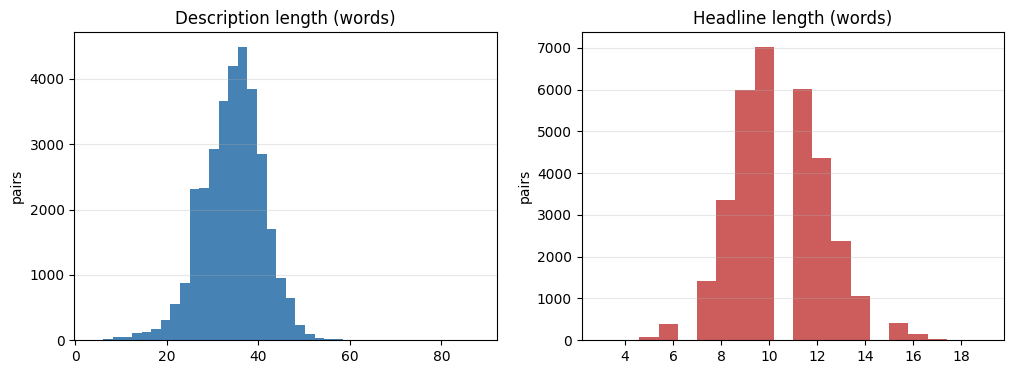

In [ ]:
import matplotlib.pyplot as plt


source_words = frame["Description"].str.split().str.len()
target_words = frame["Headlines"].str.split().str.len()

print(f"description  median {source_words.median():.0f}  95th {source_words.quantile(0.95):.0f}  max {source_words.max()}")
print(f"headline     median {target_words.median():.0f}  95th {target_words.quantile(0.95):.0f}  max {target_words.max()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(source_words, bins=40, color="steelblue")
axes[0].set_title("Description length (words)")
axes[1].hist(target_words, bins=20, color="indianred")
axes[1].set_title("Headline length (words)")
for ax in axes:
    ax.set_ylabel("pairs")
    ax.grid(True, axis="y", alpha=0.3)
plt.show()

In [ ]:
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer


MODEL_NAME = "t5-base"
SOURCE_PREFIX = "summarize: "
SOURCE_LENGTH = 128
TARGET_LENGTH = 32
SEED = 42

train, test = train_test_split(frame, test_size=0.2, random_state=SEED)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize(batch: dict) -> dict:
    tokenized = tokenizer(
        [SOURCE_PREFIX + text for text in batch["Description"]],
        truncation=True,
        max_length=SOURCE_LENGTH,
    )
    tokenized["labels"] = tokenizer(
        text_target=batch["Headlines"],
        truncation=True,
        max_length=TARGET_LENGTH,
    )["input_ids"]
    return tokenized


datasets = DatasetDict(
    {
        "train": Dataset.from_pandas(train, preserve_index=False),
        "test": Dataset.from_pandas(test, preserve_index=False),
    }
).map(tokenize, batched=True, remove_columns=COLUMNS)

for name, split in datasets.items():
    print(f"{name:<11} {len(split):>7,} rows  columns={split.column_names}")

example = datasets["train"][0]
print()
print("input: ", tokenizer.decode(example["input_ids"], skip_special_tokens=True))
print("target:", tokenizer.decode(example["labels"], skip_special_tokens=True))

Map:   0%|          | 0/26138 [00:00<?, ? examples/s]

Map:   0%|          | 0/6535 [00:00<?, ? examples/s]

train        26,138 rows  columns=['input_ids', 'attention_mask', 'labels']
test          6,535 rows  columns=['input_ids', 'attention_mask', 'labels']

input:  summarize: ** Embattled power utility company PG&E Corp will be replaced by healthcare equipment maker Teleflex Inc in the S&P 500 on Friday
target: PG&E to get pulled out of S&P 500, shares near 2001 lows


In [ ]:
import nltk
import numpy as np
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer


nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

ROUGE_KEYS = ("rouge1", "rouge2", "rougeL")


def score_summaries(predictions, actuals) -> dict[str, float]:
    """ROUGE-1/2/L F1, METEOR, and mean generation length in whitespace tokens."""
    scorer = rouge_scorer.RougeScorer(list(ROUGE_KEYS), use_stemmer=True)
    totals = dict.fromkeys(ROUGE_KEYS, 0.0)
    meteor = 0.0

    for prediction, actual in zip(predictions, actuals, strict=True):
        scores = scorer.score(actual, prediction)
        for key in ROUGE_KEYS:
            totals[key] += scores[key].fmeasure
        meteor += meteor_score([actual.split()], prediction.split())

    count = len(predictions)
    return {
        **{key: totals[key] / count for key in ROUGE_KEYS},
        "meteor": meteor / count,
        "gen_len": sum(len(p.split()) for p in predictions) / count,
    }


def compute_metrics(eval_pred) -> dict[str, float]:
    """``Seq2SeqTrainer`` entry point: restore ``-100`` to the pad token, decode, then score."""
    predictions, labels = eval_pred
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predictions = np.where(predictions != -100, predictions, tokenizer.pad_token_id)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    return score_summaries(
        tokenizer.batch_decode(predictions, skip_special_tokens=True),
        tokenizer.batch_decode(labels, skip_special_tokens=True),
    )

In [ ]:
from transformers import (
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
)



model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()

training_args = Seq2SeqTrainingArguments(
    output_dir="/content/t5-headlines",
    num_train_epochs=10,
    learning_rate=3e-4,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    weight_decay=0.01,
    warmup_steps=0,
    eval_strategy="steps",
    eval_steps=250,
    save_strategy="steps",
    save_steps=250,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,
    predict_with_generate=True,
    generation_max_length=TARGET_LENGTH,
    generation_num_beams=1,
    logging_steps=100,
    seed=SEED,
    report_to="none",
    bf16=use_bf16,
    fp16=False,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=datasets["train"],
    eval_dataset=datasets["test"],
    processing_class=tokenizer,
    data_collator=DataCollatorForSeq2Seq(tokenizer, model=model),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

steps_per_epoch = -(-len(trainer.train_dataset) // training_args.per_device_train_batch_size)
total_steps = steps_per_epoch * int(training_args.num_train_epochs)

print(f"training on {len(trainer.train_dataset):,} pairs, precision={'bf16' if use_bf16 else 'fp32'}")
print(f"validating on {len(trainer.eval_dataset):,} pairs, {total_steps // 250} times over {total_steps:,} steps")

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

training on 26,138 pairs, precision=bf16
validating on 6,535 pairs, 261 times over 65,350 steps


In [ ]:
trainer.train()

Step,Training Loss,Validation Loss


In [ ]:
history = pd.DataFrame(trainer.state.log_history)
steps = history.dropna(subset=["loss"])
evals = history.dropna(subset=["eval_loss"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(steps["epoch"], steps["loss"], label="train", alpha=0.6)
axes[0].plot(evals["epoch"], evals["eval_loss"], marker="o", label="validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

for key in ROUGE_KEYS:
    axes[1].plot(evals["epoch"], evals[f"eval_{key}"], marker="o", label=key)
axes[1].plot(evals["epoch"], evals["eval_meteor"], marker="o", label="meteor")
axes[1].set_title("Validation overlap metrics")
axes[1].set_xlabel("epoch")
axes[1].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.show()

In [ ]:
prediction = trainer.predict(datasets["test"], num_beams=4, max_length=TARGET_LENGTH)

for name, value in prediction.metrics.items():
    if name.startswith("test_") and isinstance(value, float):
        print(f"{name:<20} {value:.4f}")

test_loss            1.8439
test_rouge1          0.4813
test_rouge2          0.2398
test_rougeL          0.4390
test_meteor          0.3687
test_gen_len         10.4740
test_runtime         177.8489
test_samples_per_second 18.3750
test_steps_per_second 1.1530


In [ ]:
generated = tokenizer.batch_decode(
    np.where(prediction.predictions != -100, prediction.predictions, tokenizer.pad_token_id),
    skip_special_tokens=True,
)

for row, headline in zip(test.head(10).itertuples(), generated[:10]):
    print(f"description: {row.Description[:150]}...")
    print(f"reference:   {row.Headlines}")
    print(f"generated:   {headline}")
    print()

description: Huawei, the world's third-largest smartphone maker, presented its new flagship phone in Paris on Tuesday with the hope of making further gains in Euro...
reference:   Huawei presents flagship smartphone in Paris during Chinese leader's visit
generated:   Huawei's new flagship phone aims to make more gains in Europe

description: Three former Credit Suisse Group AG  bankers were arrested in London on Thursday on U.S. charges of involvement in a fraud involving $2 billion in loa...
reference:   Ex-Credit Suisse bankers arrested on U.S. charges over Mozambique loans
generated:   Ex-Credit Suisse bankers arrested in London over $2 billion Mozambique loan fraud

description: Samsung Electronics Co Ltd  forecast a steep plunge in its second-quarter operating profit as the U.S.-China trade war wreaks havoc in global chip and...
reference:   Samsung Electronics profit guidance beats expectations on one-off gains, outlook weak
generated:   Samsung's second-quarter profit plunges as

In [ ]:
descriptions = [
    "The central bank raised interest rates by half a percentage point on Thursday, its largest "
    "increase in more than a decade, as policymakers moved to bring down inflation that has run well "
    "above target for most of the year.",
    "Shares in the electric vehicle maker fell sharply in after-hours trading after the company "
    "reported quarterly deliveries that came in below analyst expectations, citing supply chain "
    "disruption at two of its assembly plants.",
]

batch = tokenizer(
    [SOURCE_PREFIX + text for text in descriptions],
    return_tensors="pt",
    truncation=True,
    max_length=SOURCE_LENGTH,
    padding=True,
).to(model.device)

outputs = model.generate(**batch, max_length=TARGET_LENGTH, num_beams=4)

for text, headline in zip(descriptions, tokenizer.batch_decode(outputs, skip_special_tokens=True)):
    print(f"{headline}\n  <- {text[:110]}...\n")

U.S. central bank raises rates by half a percentage point
  <- The central bank raised interest rates by half a percentage point on Thursday, its largest increase in more th...

Electric vehicle maker shares fall after quarterly deliveries miss estimates
  <- Shares in the electric vehicle maker fell sharply in after-hours trading after the company reported quarterly ...



In [ ]:
trainer.save_model("/content/t5-headlines")
tokenizer.save_pretrained("/content/t5-headlines")